In [4]:
import json, os
import matplotlib.pyplot as plt

ROOT = os.getcwd()
while not os.path.isdir(os.path.join(ROOT, "data", "abbr_dict")) and ROOT != "/":
    ROOT = os.path.dirname(ROOT)
REPORT = os.path.join(ROOT, "Report", "full")
SWEEP  = os.path.join(ROOT, "data", "abbr_dict", "sweep_results")
OPT    = os.path.join(ROOT, "data", "abbr_dict", "optimization_results")

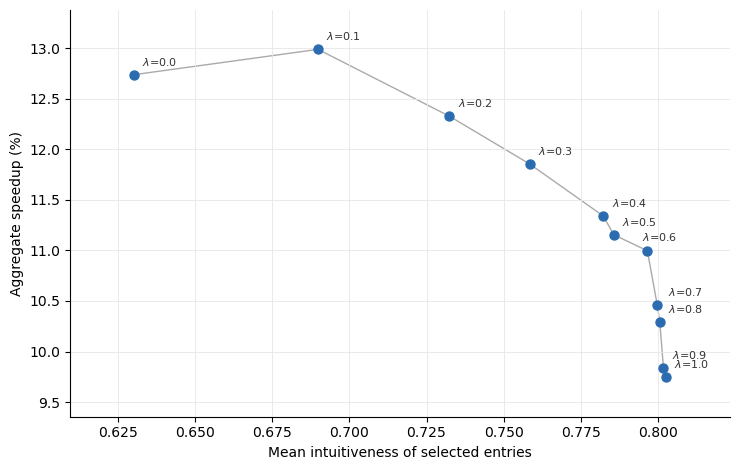

In [5]:
r = sorted(json.load(open(os.path.join(SWEEP, "eval_summary.json")))["results"], key=lambda d: d["lambda"])
lam = [d["lambda"] for d in r]
x   = [d["avg_intuitiveness"] for d in r]
y   = [d["agg_speedup_pct"] for d in r]

off = {0.6: (-4, 10, "left", "center"), 0.7: (8, 5, "left", "bottom")}

fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.plot(x, y, "-", color="#aaaaaa", lw=1, zorder=1)
ax.scatter(x, y, color="#2b6cb0", s=42, zorder=3)
for xi, yi, l in zip(x, y, lam):
    dx, dy, ha, va = off.get(round(l, 1), (6, 5, "left", "bottom"))
    ax.annotate(f"$\\lambda$={l:.1f}", (xi, yi), textcoords="offset points", xytext=(dx, dy), fontsize=8, color="#333333", ha=ha, va=va)
ax.set_xlabel("Mean intuitiveness of selected entries")
ax.set_ylabel("Aggregate speedup (%)")
ax.grid(True, color="#e6e6e6", lw=0.6, zorder=0)
ax.margins(x=0.12, y=0.12)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(os.path.join(REPORT, "abbr_pareto.png"), dpi=150)

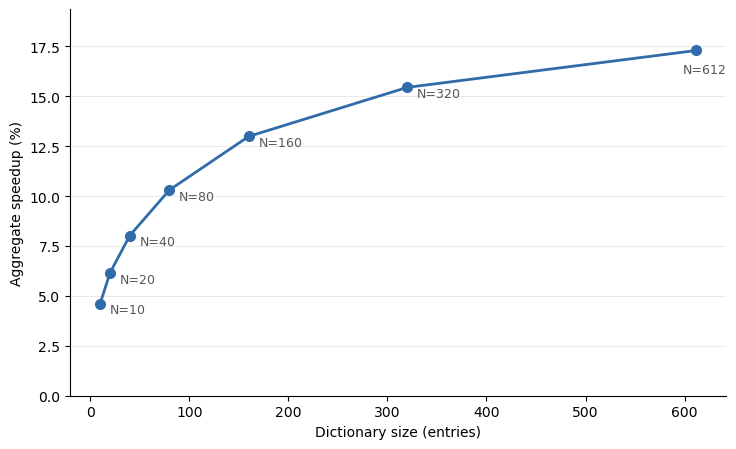

In [7]:
N = [10, 20, 40, 80, 160, 320, 640, 1280]
sizes, sp = [], []
exp = json.load(open(os.path.join(ROOT, "data", "abbr_dict", "experiments_summary.json")))["results"]
by_name = {r["name"]: r for r in exp}
seen = set()
for n in N:
    d = by_name[f"N{n}"]
    if d["dict_size"] in seen:
        continue
    seen.add(d["dict_size"])
    sizes.append(d["dict_size"]); sp.append(d["speedup_pct"])

off = {612: (-10, -16)}

fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.plot(sizes, sp, "-o", color="#316ba9", lw=2, ms=7, zorder=3)
for xi, yi in zip(sizes, sp):
    ax.annotate(f"N={xi}", (xi, yi), textcoords="offset points", xytext=off.get(xi, (7, -7)), fontsize=9, color="#555555")
ax.set_xlabel("Dictionary size (entries)")
ax.set_ylabel("Aggregate speedup (%)")
ax.set_ylim(0, max(sp) * 1.12)
ax.grid(True, axis="y", color="#e6e6e6", lw=0.6, zorder=0)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(os.path.join(REPORT, "abbr_size.png"), dpi=150)
